# Dataset A : NSW Train Occupancy Analysis
## COMP5310 Principles of Data Science : Project Stage 1

### Step 1 : Problem Definition
The objective of this analysis is to predict train occupancy levels 
in the NSW rail network based on features such as route direction, 
stop sequence order, service line, and time of day.

**Business Problem:** Transport for NSW and commuters need to understand 
occupancy patterns to reduce crowding and improve travel planning.

**Stakeholders:**
- Transport for NSW — can optimise train scheduling
- Commuters — can plan less crowded journeys
- City planners — can understand peak demand patterns

**Problem Type:** Classification — predicting Occupancy Status category

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


### Step 2 : Data Description

In [3]:
df = pd.read_csv('train_occupancy.csv')
df.head()

,day,Actual.Stop.Station,Actual.Station.Arrv.Time,Actual.Station.Dprt.Time,Segment.Direction,Trip.Name,Service.Line,Orig..Station,Dest..Station,Leading.Set.Type,Node.Seq.Order,Actual.Station.Dprt.Time.Band,Occupancy Status,Occupancy Range
0,9,Miranda,2017-01-10 00:18:17,2017-01-10 00:19:04,Down,620S,Illawarra,Central,Cronulla,T,18,00:15-00:29,MANY_SEATS_AVAILABLE,Low: 0-399
1,13,Beecroft,2017-01-13 08:05:59,2017-01-13 08:06:56,Down,152C,North via Macquarie Park,Central,Hornsby,A,16,08:00-08:14,MANY_SEATS_AVAILABLE,Low: 0-399
2,12,Arncliffe,2017-01-12 07:22:51,2017-01-12 07:23:36,Down,607B,Illawarra,Central,Waterfall,T,6,07:15-07:29,MANY_SEATS_AVAILABLE,Low: 0-399
3,13,Dulwich Hill,2017-01-13 07:20:39,2017-01-13 07:21:53,Down,58-F,Bankstown,Central,Birrong,A,7,07:15-07:29,MANY_SEATS_AVAILABLE,Low: 0-399
4,11,Belmore,2017-01-11 18:38:28,2017-01-11 18:39:07,Up,33-P,Bankstown,Birrong,Central,K,7,18:30-18:44,MANY_SEATS_AVAILABLE,Low: 0-399


In [4]:
print(df.shape) #Get the number of rows and column ( 50,250 rows , 14 columns)
print(df.dtypes) #gives the datatype of the attributes

(50250, 14)
day                              int64
Actual.Stop.Station                str
Actual.Station.Arrv.Time           str
Actual.Station.Dprt.Time           str
Segment.Direction                  str
Trip.Name                          str
Service.Line                       str
Orig..Station                      str
Dest..Station                      str
Leading.Set.Type                   str
Node.Seq.Order                   int64
Actual.Station.Dprt.Time.Band      str
Occupancy Status                   str
Occupancy Range                    str
dtype: object


In [5]:
print(df.isnull().sum()) #checks for missing/null values in the dataset and sets it True if found , sum() sums all the True values in the column)

day                               0
Actual.Stop.Station              74
Actual.Station.Arrv.Time          7
Actual.Station.Dprt.Time         11
Segment.Direction                78
Trip.Name                         0
Service.Line                     59
Orig..Station                    80
Dest..Station                    63
Leading.Set.Type                 77
Node.Seq.Order                    0
Actual.Station.Dprt.Time.Band     0
Occupancy Status                 73
Occupancy Range                   0
dtype: int64


In [6]:
print(df.duplicated().sum())

250


## Step 3 : Data Cleaning

**Note:** During Step 4 (EDA), additional data quality issues were discovered in the Occupancy Status and Segment.Direction columns.    Occupancy Status had inconsistent capitalisation, a missing underscore (MANY_SEATSAVAILABLE), and a typographical error(VTANDING_ROOM_ONLY). Segment.Direction had trailing whitespace causing it to appear as 4 categories instead of 2. These were cleaned iteratively and the fixes are documented within Step 3 for clarity. The final cleaned dataset reflects all corrections applied.


In [7]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with missing values
df = df.dropna()

# Verify the cleaning
print(f"Rows after cleaning: {df.shape[0]}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"Duplicates remaining: {df.duplicated().sum()}")

Rows after cleaning: 49482
Missing values remaining: 0
Duplicates remaining: 0


In [8]:
df.to_csv("train_occupancy_cleaned.csv", index=False)
print("Cleaned dataset saved")

Cleaned dataset saved


In [9]:
print("Occupancy Status values:")
print(df['Occupancy Status'].value_counts())

print("\nService Line values:")
print(df['Service.Line'].value_counts())

Occupancy Status values:
Occupancy Status
MANY_SEATS_AVAILABLE    47344
FEW_SEATS_AVAILABLE      1573
STANDING_ROOM_ONLY        394
MANY_SEATSAVAILABLE       161
few_seats_available         8
VTANDING_ROOM_ONLY          2
Name: count, dtype: int64

Service Line values:
Service.Line
Illawarra                    7474
West                         6161
North Shore                  4755
Airport                      4523
Bankstown                    4094
South                        3599
City Circle                  3151
North  via Macquarie Park    3063
North                        2738
Eastern Suburbs              2248
Inner West                   2177
North  via  Strathfield      1695
Hunter Valley                1076
Cumberland                   1042
Olympic Park West/South       519
Carlingford Shuttle           296
Illawarra to Sydney           188
North Coast                   158
East Hills                    152
South Coast                   141
Port Kembla                   135
NOR

In [ ]:
#The results show 2 different sets of Ups and Downs so we need to analyse it
print("Segment Direction values:")
print(df['Segment.Direction'].value_counts())

Segment Direction values:
Segment.Direction
Up       24860
Down     24466
Up          79
Down        77
Name: count, dtype: int64


In [ ]:
# After checking for unique values in the column , whitespaces r found hence was assumed to be of different class
print(df['Segment.Direction'].unique())

<StringArray>
['Down', 'Up', 'Up ', 'Down ']
Length: 4, dtype: str


In [12]:
# Fix trailing spaces in Segment.Direction
df['Segment.Direction'] = df['Segment.Direction'].str.strip()

# Verify the fix
print(df['Segment.Direction'].value_counts())

Segment.Direction
Up      24939
Down    24543
Name: count, dtype: int64


## Step 4 : Exploratory Data Analysis

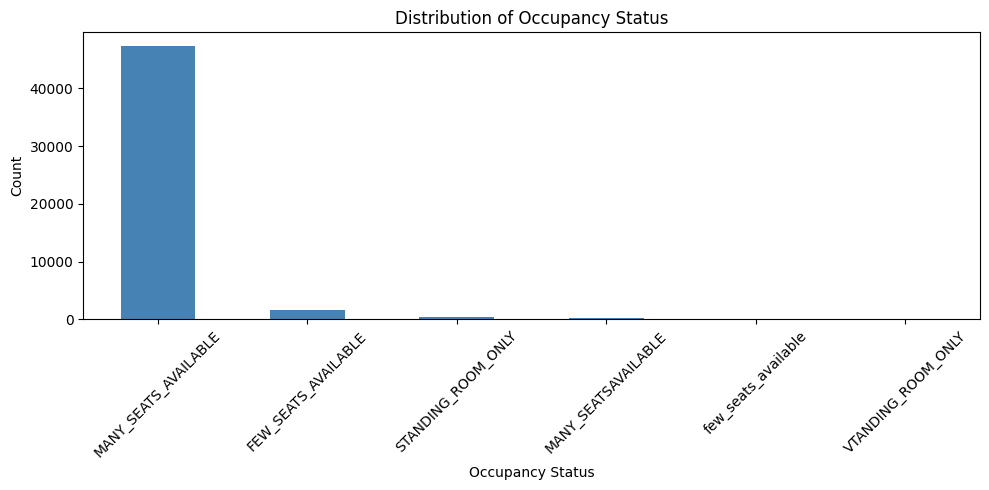

In [ ]:
# Chart 1 - Occupancy Status distribution
plt.figure(figsize=(10, 5))
df['Occupancy Status'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribution of Occupancy Status')
plt.xlabel('Occupancy Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#Many_SEATSAVAILABLE, few_seats_available , VTANDING_ROOM_ONLY r inconsistent data quality issues that we need to fix

In [15]:
#Fixing all the errors 

df['Occupancy Status'] = df['Occupancy Status'].str.strip().str.upper()
df['Occupancy Status'] = df['Occupancy Status'].replace({

    'MANY_SEATSAVAILABLE' : 'MANY_SEATS_AVAILABLE',
    'VTANDING_ROOM_ONLY' : 'STANDING_ROOM_ONLY'
})

print(df['Occupancy Status'].value_counts())

Occupancy Status
MANY_SEATS_AVAILABLE    47505
FEW_SEATS_AVAILABLE      1581
STANDING_ROOM_ONLY        396
Name: count, dtype: int64


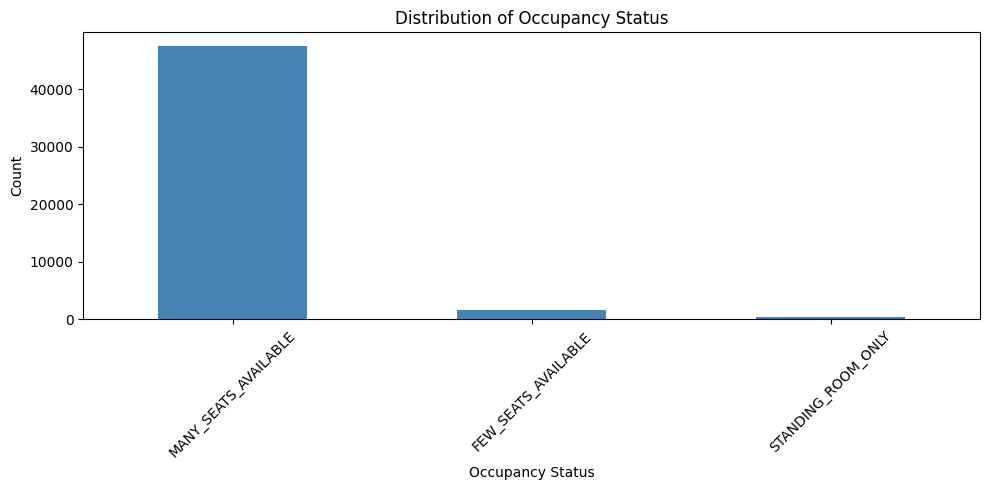

In [16]:
plt.figure(figsize=(10, 5))
df['Occupancy Status'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribution of Occupancy Status')
plt.xlabel('Occupancy Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

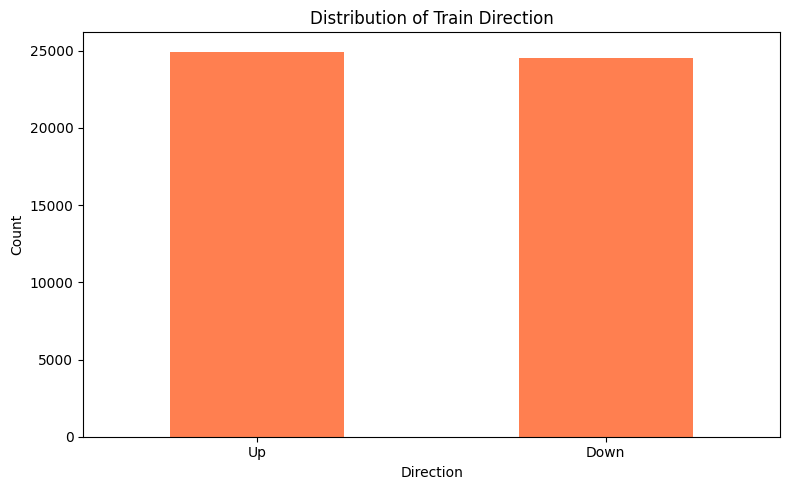

In [17]:
#Chart 2 for Categorical data Segment.Direction

plt.figure(figsize=(8, 5))
df['Segment.Direction'].value_counts().plot(kind='bar', color='coral')
plt.title('Distribution of Train Direction')
plt.xlabel('Direction')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

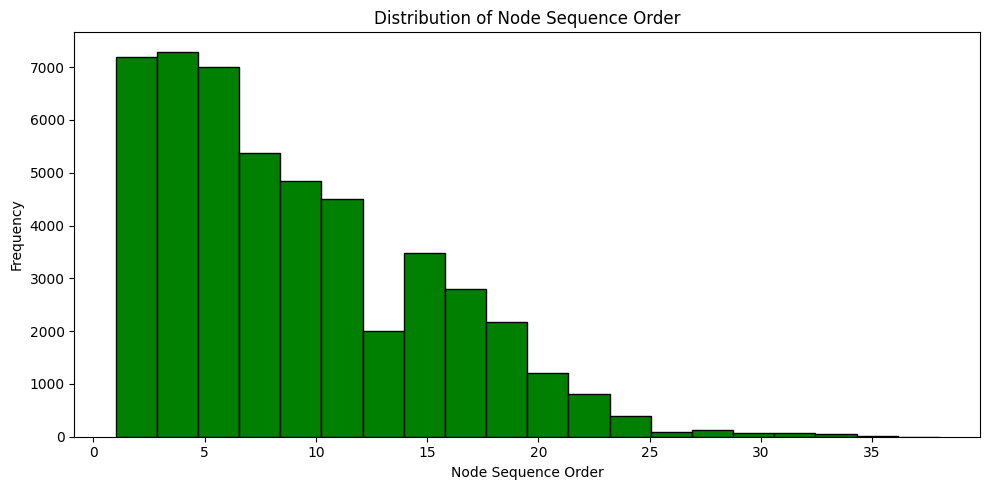

In [18]:
#Chart 1 for numerical columns - Node Sequence Order 

plt.figure(figsize=(10, 5))
df['Node.Seq.Order'].plot(kind='hist', bins=20, color='green', edgecolor='black')
plt.title('Distribution of Node Sequence Order')
plt.xlabel('Node Sequence Order')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

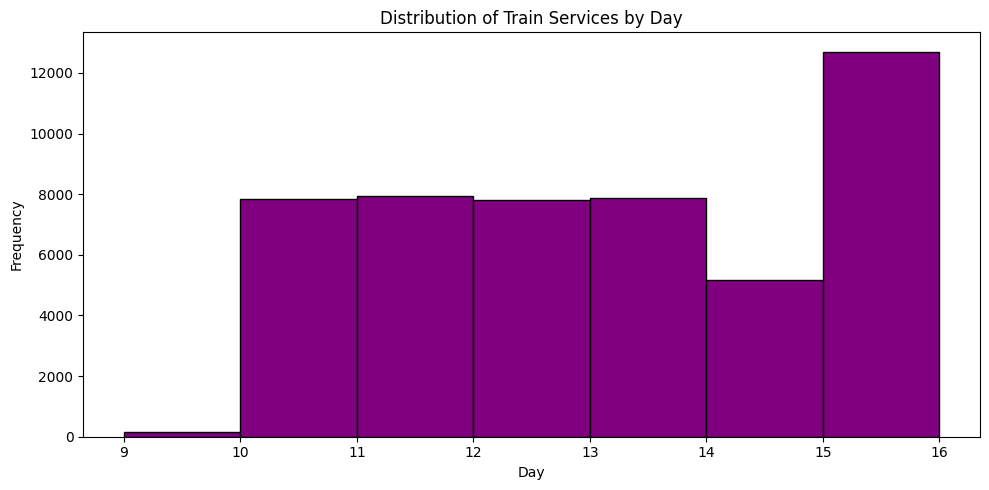

In [19]:
# Chart 2 for numerical column -  day 

plt.figure(figsize=(10, 5))
df['day'].plot(kind='hist', bins=7, color='purple', edgecolor='black')
plt.title('Distribution of Train Services by Day')
plt.xlabel('Day')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [20]:
print(df['day'].unique())
print(df['day'].min())
print(df['day'].max())

[ 9 13 12 11 10 15 14 16]
9
16


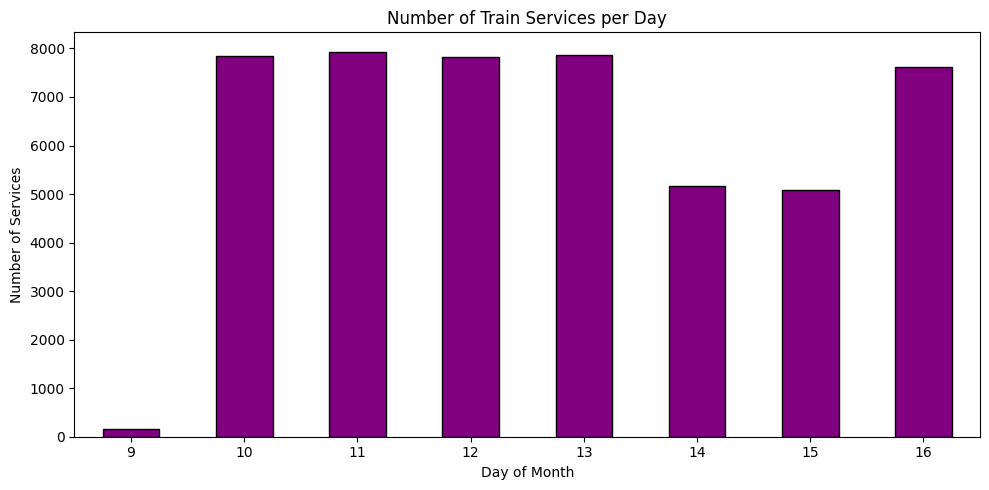

In [21]:
#Chart 2 for numerical column for day - using bar chart instead since the values r discrete its cleaner with bar 

plt.figure(figsize=(10, 5))
df['day'].value_counts().sort_index().plot(kind='bar', color='purple', edgecolor='black')
plt.title('Number of Train Services per Day')
plt.xlabel('Day of Month')
plt.ylabel('Number of Services')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
#Correlation between the 2 numerical columns

print(df[['day', 'Node.Seq.Order']].corr())

                     day  Node.Seq.Order
day             1.000000       -0.009227
Node.Seq.Order -0.009227        1.000000


In [23]:
# Save final cleaned dataset with all fixes applied
df.to_csv('train_occupancy_cleaned.csv', index=False)
print(f"Final cleaned dataset saved!")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

Final cleaned dataset saved!
Shape: (49482, 14)
Missing values: 0
